# Notebook 01 — Options Basics

Covers: calls/puts, intrinsic value, payoff diagrams, spreads, straddle, strangle.

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt
from strategies import *
from plots import plot_payoff
SPOT = STRIKE = 19_500
CALL_P = 200
PUT_P = 190
print("Ready")

Matplotlib is building the font cache; this may take a moment.


Ready


## 1. Intrinsic value

At expiry:
- Call = max(S − K, 0)
- Put  = max(K − S, 0)

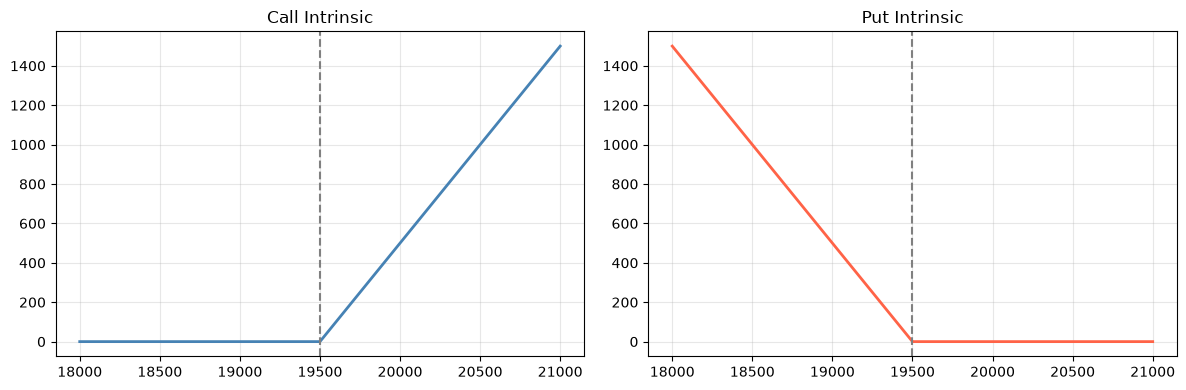

In [2]:
spots = np.linspace(18000, 21000, 500)
K = 19500
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(spots, np.maximum(spots-K,0), color="steelblue", lw=2)
ax1.set_title("Call Intrinsic"); ax1.axvline(K, color="gray", ls="--"); ax1.grid(alpha=0.3)
ax2.plot(spots, np.maximum(K-spots,0), color="tomato", lw=2)
ax2.set_title("Put Intrinsic"); ax2.axvline(K, color="gray", ls="--"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Long Call

Pay premium upfront. Profit if spot rises above breakeven.
**Breakeven = Strike + Premium paid**

In [ ]:
strat = long_call(STRIKE, CALL_P)
print(strat)
plot_payoff(strat); plt.show()

## 3. Long Put

Pay premium upfront. Profit if spot falls below breakeven.
**Breakeven = Strike − Premium paid**

In [ ]:
strat = long_put(STRIKE, PUT_P)
print(strat)
plot_payoff(strat); plt.show()

## 4. Short Call and Short Put

Flip the payoff — collect premium but take on the risk.
This is the seller's perspective.

In [ ]:
from strategies import short_put
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
for ax, s, color, title in [
    (ax1, short_call(STRIKE, CALL_P), "steelblue", "Short Call"),
    (ax2, short_put(STRIKE, PUT_P),  "tomato",    "Short Put"),
]:
    pnl = s.payoff(spots)
    ax.plot(spots, pnl, color=color, lw=2)
    ax.axhline(0, color="gray", ls="--")
    ax.fill_between(spots, pnl, 0, where=(pnl>=0), alpha=0.15, color="green")
    ax.fill_between(spots, pnl, 0, where=(pnl<0),  alpha=0.15, color="red")
    ax.set_title(title, fontweight="bold"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Bull Call Spread

Buy lower strike call + sell higher strike call.
Cheaper than naked call, but profit is capped.

In [ ]:
strat = bull_call_spread(19400, 19600, 320, 160)
print(strat)
plot_payoff(strat); plt.show()

## 6. Short Straddle — Core Backtest Strategy

Sell ATM call + sell ATM put at the same strike.
- Collect premium upfront
- Win if market stays near strike
- Lose on large move in either direction

**Thesis:** IV > RV on average → selling premium is structurally profitable.

In [ ]:
strat = short_straddle(STRIKE, CALL_P, PUT_P)
print(strat)
plot_payoff(strat, title="Short Straddle — Core Strategy"); plt.show()

## 7. Straddle vs Strangle

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))
for s, color, label in [
    (short_straddle(STRIKE, CALL_P, PUT_P),        "steelblue",  "Short Straddle"),
    (short_strangle(19700, 19300, 110, 105), "darkorange", "Short Strangle"),
]:
    ax.plot(spots, s.payoff(spots), color=color, lw=2.5, label=label)
ax.axhline(0, color="gray")
ax.set_title("Straddle vs Strangle", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 8. Summary table

In [ ]:
import pandas as pd
all_s = [long_call(STRIKE,CALL_P), long_put(STRIKE,PUT_P),
         short_call(STRIKE,CALL_P), short_put(STRIKE,PUT_P),
         bull_call_spread(19400,19600,320,160),
         bear_put_spread(19600,19400,310,160),
         long_straddle(STRIKE,CALL_P,PUT_P),
         short_straddle(STRIKE,CALL_P,PUT_P),
         short_strangle(19700,19300,110,105)]
rows = [{k:v for k,v in s.summary().items()} for s in all_s]
pd.DataFrame(rows)

---
**Next:** Notebook 02 — Black-Scholes pricing and Greeks.